In [1]:

# Uncomment to download the packets
#!pip install matplotlib
#!pip install seaborn
#!pip install tqdm

In [2]:
# Library Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

# Set visualization style for the research notebook
sns.set_theme(style="whitegrid")

# Preamble

This simulation is run with the dataset1, which has been generated with the following parameters

| Parameter | Value | Meaning in the Simulation |
| :--- | :--- | :--- |
| **`N` (Sample Size)** | **250** | The total size of your dataset. Since you are simulating "Balanced" clusters, this means you will have exactly **125 points in Cluster A** and **125 points in Cluster B**. |
| **`p` (Variables)** | **2** | The number of dimensions ($X_1, X_2$). This is crucial because $p=2$ allows us to visualize the data easily on a 2D Scatter Plot. If $p$ were 10, the math works the same, but we couldn't see it easily. |
| **`rho` ($\rho$)** | **0.0** | The correlation between $X_1$ and $X_2$ *within* a cluster. <br>• **0.0:** The clusters are **Spherical** (round blobs). <br>• **0.9:** The clusters would be narrow, diagonal ellipses. |
| **`separation`** | **10** | The distance between the centers of the two clusters (in standard deviations). <br>• **10:** **Extremely Easy.** The clusters are far apart with zero overlap. <br>• **0.1:** **Impossible.** The clusters are on top of each other (pure noise). |
| **`k` (Clusters)** | **2** | The "Ground Truth." We *know* there are 2 groups. The goal of the simulation is to see if the clustering algorithm can figure this out looking only at the synthetic data. |
| **`method`** | **CART** | **C**lassification **A**nd **R**egression **T**rees. This is the algorithm used to create the synthetic data. It builds a decision tree to learn the rules of the real data and generates new points based on those rules. |
| **`m`** | **1** | We are generating a single synthetic dataset for this specific test. In the full simulation later, `m` will be 50 to get statistical averages. |

In [3]:
# ==========================================
# Configuration for Dataset 1
# ==========================================

# 1. Data Dimensions
N = 250            # Total number of observations (rows)
p = 2              # Number of variables/features (columns)

# 2. Cluster Properties
k = 2              # Number of clusters (groups)
rho = 0.0          # Correlation between variables (shape of cluster)
separation = 10    # Distance between cluster centroids (signal strength)

# 3. Synthesis Parameters
method = "CART"    # Method used to generate synthetic data
m = 1              # Number of synthetic datasets to generate

# Hierarchical (Agglomerative) Clustering

To extend the validation study, we now replace K-Means with Hierarchical Clustering using Ward's method.

## Technical Definition
Agglomerative Hierarchical Clustering is a **bottom-up** clustering algorithm. Each observation starts as its own cluster, and pairs of clusters are iteratively merged based on a linkage criterion until only $k$ clusters remain.

## Ward's Linkage (ward.D2)
We use **Ward's minimum variance method**, which minimizes the total within-cluster variance at each merge step. This objective is mathematically aligned with K-Means' goal of minimizing within-cluster sum of squares (WCSS).

$$\Delta(A, B) = \frac{n_A \cdot n_B}{n_A + n_B} \|\bar{x}_A - \bar{x}_B\|^2$$

Where $\Delta(A, B)$ is the increase in total variance when merging clusters $A$ and $B$.

## Key Differences from K-Means

| Aspect | K-Means | Hierarchical (Ward) |
|--------|---------|---------------------|
| **Approach** | Partitioning (top-down assignment) | Agglomerative (bottom-up merging) |
| **Initialization** | Random centroids (sensitive to init) | Deterministic (no randomness) |
| **Centroids** | Updated iteratively | Computed post-hoc from labels |
| **Dendrogram** | Not available | Can visualize full hierarchy |

## Why Ward's Method?
- **Deterministic:** No random initialization means reproducible results
- **Variance-based:** Same objective as K-Means (minimize WCSS)
- **R Compatibility:** Matches R's `hclust(method="ward.D2")`

In [4]:
# Let's start by defining original and synthetic data paths.
ORIGINAL_DATA_PATH = "../data/1/original_data.csv"
SYNTHETIC_DATA_PATH = "../data/1/synthetic_data.csv"

# I will also fix now some parameters such as:
RND = 123
NUM_INIT = 100

In [5]:

# ==========================================
# 1. Gini Coefficient
# ==========================================
def gini_coefficient(x):
    """
    Calculate the Gini coefficient of a numpy array.
    Replicates the behavior of R's DescTools::Gini.
    """
    x = np.array(x, dtype=np.float64)
    if np.amin(x) < 0:
        x -= np.amin(x) # Ensure non-negative
    x += 0.0000001      # Avoid division by zero
    
    x = np.sort(x)
    n = x.shape[0]
    index = np.arange(1, n + 1)
    
    return ((np.sum((2 * index - n - 1) * x)) / (n * np.sum(x)))

# ==========================================
# 2. Compute Cluster Centroids (for Hierarchical)
# ==========================================
def compute_centroids(data_scaled, labels):
    """
    Compute cluster centroids from labels.
    Required for Hierarchical clustering since it doesn't output centroids natively.
    """
    unique_labels = np.unique(labels)
    centroids = np.array([data_scaled[labels == label].mean(axis=0) for label in unique_labels])
    return centroids

# ==========================================
# 3. Optimal K Decision (The Decider) - HIERARCHICAL VERSION
# ==========================================
def get_optimal_k(data, max_k=10):
    """
    Finds optimal k using Silhouette Score with Hierarchical Clustering (Ward).
    Simulates the logic of fviz_nbclust but with AgglomerativeClustering.
    """
    best_score = -1
    best_k = 2
    best_labels = None
    
    # Scale data (Crucial for distance-based clustering)
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)

    # Iterate to find the k with the highest Silhouette Score
    for k in range(2, max_k + 1):
        hc = AgglomerativeClustering(
            n_clusters=k,
            linkage='ward'  # Matches R's ward.D2
        )
        labels = hc.fit_predict(data_scaled)
        score = silhouette_score(data_scaled, labels)
        
        if score > best_score:
            best_score = score
            best_k = k
            best_labels = labels
    
    # Compute centroids for the best k
    centroids = compute_centroids(data_scaled, best_labels)
            
    return best_k, best_labels, centroids, data_scaled

# ==========================================
# 4. Label Switching (The Translator)
# ==========================================
def match_clusters(real_centroids, syn_centroids):
    """
    Matches synthetic labels to real labels using the Hungarian Algorithm
    on the centroids' Euclidean distances.
    """
    # Calculate distance matrix between all Real and Syn centroids
    dists = cdist(real_centroids, syn_centroids, metric='euclidean')
    
    # Solve the Linear Sum Assignment Problem (Hungarian Algo)
    # This finds the pairing that minimizes total distance
    real_indices, syn_indices = linear_sum_assignment(dists)
    
    # Create a map: {Synthetic_Label -> Real_Label}
    mapping = {syn_idx: real_idx for real_idx, syn_idx in zip(real_indices, syn_indices)}
    
    return mapping

In [6]:
# 1. Load Data
real_df = pd.read_csv(ORIGINAL_DATA_PATH)
syn_df = pd.read_csv(SYNTHETIC_DATA_PATH)

feature_cols = ['X1', 'X2']
X_real = real_df[feature_cols].copy()
X_syn = syn_df[feature_cols].copy()

# 2. Cluster REAL Data (Hierarchical with Ward linkage)
real_k, real_labels, real_centroids, real_scaled = get_optimal_k(X_real)
real_counts = np.bincount(real_labels)

# 3. Cluster SYNTHETIC Data (Forcing k to match Real, per methodology)
scaler = StandardScaler()
syn_scaled = scaler.fit_transform(X_syn)

syn_model = AgglomerativeClustering(n_clusters=real_k, linkage='ward')
syn_labels_raw = syn_model.fit_predict(syn_scaled)
syn_centroids = compute_centroids(syn_scaled, syn_labels_raw)

# 4. Apply Label Switching
mapping = match_clusters(real_centroids, syn_centroids)
syn_labels_mapped = np.array([mapping[label] for label in syn_labels_raw])
syn_counts = np.bincount(syn_labels_mapped)

# 5. Calculate Metrics
metrics = {
    "Metric": ["Optimal k", "Gini Coeff", "Silhouette"],
    "Real Data": [
        real_k, 
        gini_coefficient(real_counts), 
        silhouette_score(real_scaled, real_labels)
    ],
    "Synthetic Data": [
        real_k, 
        gini_coefficient(syn_counts), 
        silhouette_score(syn_scaled, syn_labels_mapped)
    ]
}

# Display Results
results_df = pd.DataFrame(metrics)
results_df["Diff"] = results_df["Real Data"] - results_df["Synthetic Data"]
display(results_df)

,Metric,Real Data,Synthetic Data,Diff
0,Optimal k,2.000000,2.000000,0.000000
1,Gini Coeff,0.000000,0.020000,-0.020000
2,Silhouette,0.771373,0.786775,-0.015402


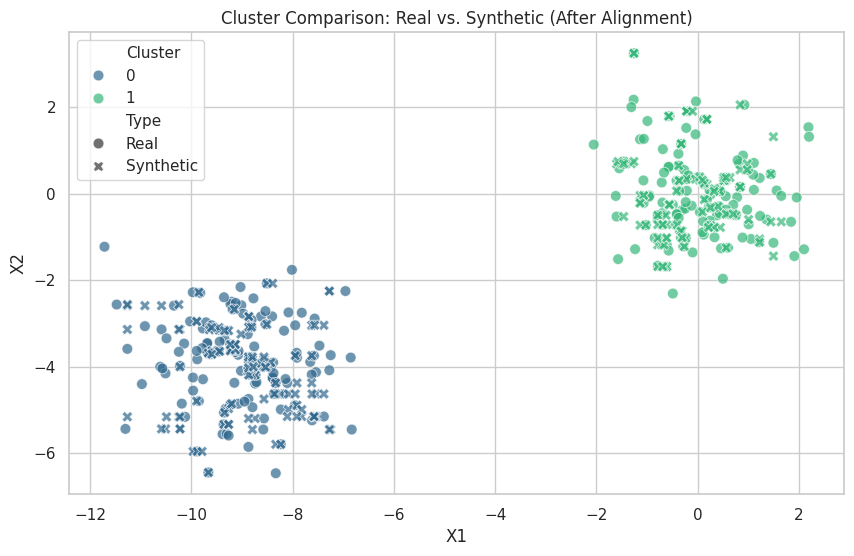

In [7]:
# Prepare data for plotting
plot_data = pd.concat([
    pd.DataFrame(X_real).assign(Cluster=real_labels, Type='Real'),
    pd.DataFrame(X_syn).assign(Cluster=syn_labels_mapped, Type='Synthetic')
])

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_data, x='X1', y='X2', 
    hue='Cluster', style='Type', 
    palette='viridis', s=60, alpha=0.7
)
plt.title(f"Cluster Comparison: Real vs. Synthetic (After Alignment)")
plt.show()

In [8]:
# Ensure you have these imports
from joblib import Parallel, delayed
import pandas as pd
import time

# If you saved your generation functions in 'generate_and_save.py', import them:
# from generate_and_save import generate_original_data, generate_synthetic_cart
# OR, if they are defined in the notebook, just ensure this cell runs after them.

def simulate_one(params):
    """
    Worker function for parallel processing.
    Generates data, synthesizes it, and calculates metrics.
    """
    try:
        # 1. Unpack Parameters
        N, p, k = params['N'], params['p'], params['k']
        rho, sep = params['rho'], params['separation']
        seed = params['seed']
        
        # 2. Generate Data (Fresh for this seed)
        real_df = generate_original_data(N, p, rho, sep, k, seed=seed)
        
        # 3. Synthesize Data
        syn_df = generate_synthetic_cart(real_df, seed=seed)
        
        # 4. Prepare for Clustering (Drop labels)
        X_real = real_df.drop(columns=['group'])
        X_syn = syn_df.drop(columns=['group'])
        
        # 5. Cluster REAL Data (Find optimal k)
        # We scan k=2..5 to see if it finds the truth
        real_k_found, real_model, real_scaled = get_optimal_k(X_real, max_k=5, random_state=seed)
        
        # 6. Cluster SYNTHETIC Data
        # Force k to match what was found in Real data (mimicking 'k.real' from R)
        scaler = StandardScaler()
        syn_scaled = scaler.fit_transform(X_syn)
        
        syn_model = KMeans(
            n_clusters=k,
            n_init=50,            # match R's nstart
            algorithm="lloyd",    # closest to R default
            max_iter=10,          # match R max iterations
            random_state=RND
        )
        syn_labels_raw = syn_model.fit_predict(syn_scaled)
        
        # 7. Match Labels (Hungarian Algorithm)
        mapping = match_clusters(real_model, syn_model)
        syn_labels_mapped = np.array([mapping[label] for label in syn_labels_raw])
        
        # 8. Calculate Metrics
        # Real
        real_labels = real_model.labels_
        real_counts = np.bincount(real_labels)
        real_gini = gini_coefficient(real_counts)
        real_sil = silhouette_score(real_scaled, real_labels)
        
        # Synthetic
        syn_counts = np.bincount(syn_labels_mapped)
        syn_gini = gini_coefficient(syn_counts)
        syn_sil = silhouette_score(syn_scaled, syn_labels_mapped)
        
        # Success? (Did Real Data clustering find the correct k?)
        success = 1 if real_k_found == k else 0
        
        # 9. Return Result Row
        return {
            "N": N, "p": p, "k": k, "rho": rho, "separation": sep,
            "seed": seed,
            "k_found": real_k_found,
            "success": success,
            "Gini_Real": real_gini,
            "Gini_Syn": syn_gini,
            "Diff_Gini": real_gini - syn_gini,
            "Sil_Real": real_sil,
            "Sil_Syn": syn_sil,
            "Diff_Sil": real_sil - syn_sil
        }
        
    except Exception as e:
        # Handle crashes gracefully so the whole loop doesn't fail
        return {"error": str(e), **params}

In [9]:
# Define your experimental factors
N_list = [250]
p_list = [2, 5, 10]
k_list = [2, 3, 4]
rho_list = [0.0] # Add 0.5, 0.9 later if needed
separation_list = [0.1, 2, 6, 10]
n_simulations = 50 # Total 'm' per setting

# Create the grid of all jobs
param_grid = []

# Iterate through all combinations
import itertools

keys = ['N', 'p', 'k', 'rho', 'separation']
combinations = itertools.product(N_list, p_list, k_list, rho_list, separation_list)

for values in combinations:
    base_params = dict(zip(keys, values))
    
    # Add 50 seeds for each combination
    for i in range(n_simulations):
        # Create a unique seed for every single run to ensure randomness
        # e.g. seed = 1000 * iteration + i
        params = base_params.copy()
        params['seed'] = i + (hash(str(values)) % 100000) 
        params['method'] = 'CART'
        param_grid.append(params)

print(f"Total simulations to run: {len(param_grid)}")
# Expected: 1 (N) * 3 (p) * 3 (k) * 1 (rho) * 4 (sep) * 50 (m) = 1,800 jobs

Total simulations to run: 1800


🚀 Starting HIERARCHICAL Clustering Simulation: 36 factor combinations
📋 Algorithm: AgglomerativeClustering (linkage='ward')
📋 Each combination: 5 independent runs × 50 synthetic datasets
📋 Total synthetic datasets tested: 9000


Processing: 100%|██████████| 36/36 [00:36<00:00,  1.02s/it]



📊 HIERARCHICAL CLUSTERING Results Summary
    k   p  separation  success_rate  success_std
0   2   2         0.1         0.012     0.009798
1   2   2         2.0         0.132     0.151050
2   2   2         6.0         0.984     0.032000
3   2   2        10.0         0.896     0.198151
4   3   2         0.1         0.104     0.029394
5   3   2         2.0         0.172     0.117712
6   3   2         6.0         1.000     0.000000
7   3   2        10.0         1.000     0.000000
8   4   2         0.1         0.044     0.034409
9   4   2         2.0         0.092     0.037094
10  4   2         6.0         0.992     0.016000
11  4   2        10.0         1.000     0.000000
12  2   5         0.1         0.148     0.060133
13  2   5         2.0         0.292     0.068819
14  2   5         6.0         1.000     0.000000
15  2   5        10.0         1.000     0.000000
16  3   5         0.1         0.028     0.016000
17  3   5         2.0         0.116     0.040792
18  3   5         6.0     

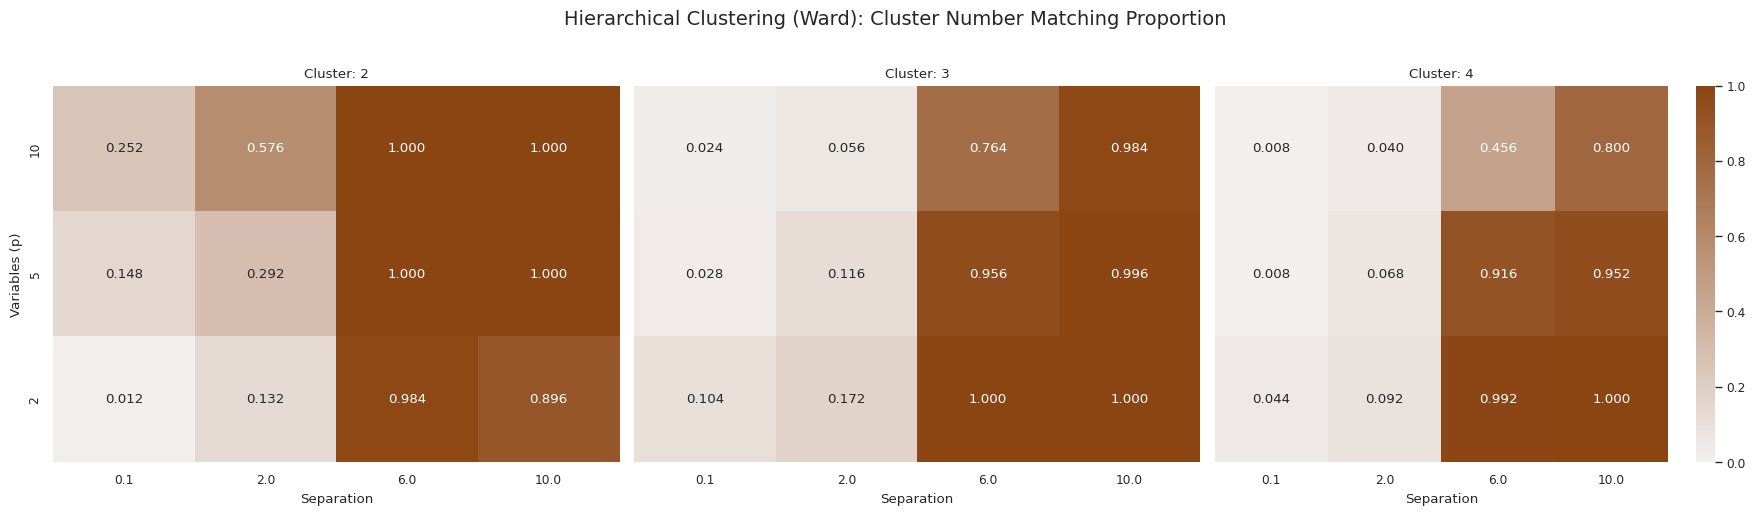


📊 SUMMARY TABLE: Success Rate by (k, p, separation)
separation   0.1    2.0    6.0    10.0
k p                                   
2 2         0.012  0.132  0.984  0.896
  5         0.148  0.292  1.000  1.000
  10        0.252  0.576  1.000  1.000
3 2         0.104  0.172  1.000  1.000
  5         0.028  0.116  0.956  0.996
  10        0.024  0.056  0.764  0.984
4 2         0.044  0.092  0.992  1.000
  5         0.008  0.068  0.916  0.952
  10        0.008  0.040  0.456  0.800


In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from tqdm import tqdm
from sklearn.tree import DecisionTreeRegressor
from scipy.stats import multivariate_normal
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
import itertools

# Set plot style
sns.set_theme(style="whitegrid", context="paper")

# ==========================================
# 1. HELPER FUNCTIONS - Data Generation (Same as K-Means)
# ==========================================

def generate_centroids(k, p, separation):
    """Matches R's centroid.generation exactly."""
    centroids = np.zeros((k, p))
    centroids[0, :] = 0
    for i in range(1, k):
        tries = 0
        while True:
            vector = np.random.normal(0, 1, p)
            vector = (vector / np.linalg.norm(vector)) * separation
            dists = np.linalg.norm(centroids[:i, :] - vector, axis=1)
            if np.all(dists >= separation):
                centroids[i, :] = vector
                break
            tries += 1
            if tries > 1000:
                raise ValueError("Could not generate separated centroids.")
    return centroids

def generate_original_data(N, p, rho, separation, k, seed=None):
    """Matches R's data.generation exactly."""
    if seed is not None:
        np.random.seed(seed)
    centroids = generate_centroids(k, p, separation)
    
    R = np.full((p, p), rho)
    np.fill_diagonal(R, 1)
    Sigma = R
    
    data_list = []
    n_per_cluster = round(N / k)
    for i in range(k):
        cluster_data = multivariate_normal.rvs(mean=centroids[i], cov=Sigma, size=n_per_cluster)
        if p == 1:
            cluster_data = cluster_data.reshape(-1, 1)
        df = pd.DataFrame(cluster_data, columns=[f'X{j+1}' for j in range(p)])
        df['group'] = i + 1
        data_list.append(df)
    return pd.concat(data_list, ignore_index=True)

def generate_synthetic_cart(real_data, seed=None, min_samples_leaf=10):
    """
    Synthesize data using CART (Decision Trees).
    
    CRITICAL: min_samples_leaf=10 matches R's synthpop smoothing behavior.
    """
    if seed:
        np.random.seed(seed)
        
    data_to_synth = real_data.drop(columns=['group'])
    n_rows, n_cols = data_to_synth.shape
    syn_data = pd.DataFrame(index=range(n_rows), columns=data_to_synth.columns)
    
    # Bootstrap the training data (matches R's proper=TRUE)
    bootstrap_idx = np.random.choice(n_rows, size=n_rows, replace=True)
    train_data = data_to_synth.iloc[bootstrap_idx].reset_index(drop=True)
    
    # First variable: Simple Bootstrap resampling
    first_col = data_to_synth.columns[0]
    syn_data[first_col] = np.random.choice(train_data[first_col], size=n_rows, replace=True)
    
    # Subsequent variables: CART
    for i in range(1, n_cols):
        target_col = data_to_synth.columns[i]
        feature_cols = data_to_synth.columns[:i]
        
        X_train = train_data[feature_cols].values
        y_train = train_data[target_col].values
        
        tree = DecisionTreeRegressor(random_state=seed, min_samples_leaf=min_samples_leaf)
        tree.fit(X_train, y_train)
        
        X_syn = syn_data[feature_cols].values
        leaves = tree.apply(X_syn)
        train_leaves = tree.apply(X_train)
        
        syn_values = np.zeros(n_rows)
        for row_idx in range(n_rows):
            leaf_id = leaves[row_idx]
            values_in_leaf = y_train[train_leaves == leaf_id]
            
            if len(values_in_leaf) > 0:
                syn_values[row_idx] = np.random.choice(values_in_leaf)
            else:
                syn_values[row_idx] = tree.predict(X_syn[row_idx].reshape(1, -1))[0]
                
        syn_data[target_col] = syn_values

    syn_data['group'] = real_data['group'].values
    return syn_data

# ==========================================
# 2. HIERARCHICAL CLUSTERING FUNCTIONS
# ==========================================

def compute_centroids_from_labels(data_scaled, labels):
    """Compute cluster centroids from labels (required for Hierarchical)."""
    unique_labels = np.unique(labels)
    centroids = np.array([data_scaled[labels == label].mean(axis=0) for label in unique_labels])
    return centroids

def k_decision_hierarchical(data, k_real=None, synthetic=False):
    """
    Finds optimal k using Silhouette Score with Hierarchical Clustering (Ward).
    Drop-in replacement for k_decision using AgglomerativeClustering.
    """
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)
    
    best_score = -1
    k_opt = 2
    
    for k in range(2, 11):
        hc = AgglomerativeClustering(n_clusters=k, linkage='ward')
        labels = hc.fit_predict(data_scaled)
        score = silhouette_score(data_scaled, labels)
        if score > best_score:
            best_score = score
            k_opt = k
    
    if not synthetic:
        # Fit final model with optimal k
        hc_final = AgglomerativeClustering(n_clusters=k_opt, linkage='ward')
        labels_final = hc_final.fit_predict(data_scaled)
        centroids = compute_centroids_from_labels(data_scaled, labels_final)
        return {"k_opt": k_opt, "labels": labels_final, "centroids": centroids, "scaled_data": data_scaled}
    else:
        if k_opt == k_real:
            hc_final = AgglomerativeClustering(n_clusters=k_opt, linkage='ward')
            labels_final = hc_final.fit_predict(data_scaled)
            centroids = compute_centroids_from_labels(data_scaled, labels_final)
            return {"k_opt": k_opt, "labels": labels_final, "centroids": centroids, "scaled_data": data_scaled}
        else:
            return None

def simulate_one_run_hierarchical(factor_combination, run_seed, total_m=50, max_attempts=200):
    """
    Single run using Hierarchical Clustering (Ward linkage).
    """
    N = factor_combination['N']
    p = factor_combination['p']
    k = factor_combination['k']
    rho = factor_combination['rho']
    separation = factor_combination['separation']
    
    # Step 1: Find a real dataset where k_decision finds the correct k
    found_real = False
    real_data = None
    k_real = None
    
    for attempt in range(1, max_attempts + 1):
        seed = run_seed * 1000 + attempt
        np.random.seed(seed)
        try:
            real_data = generate_original_data(N, p, rho, separation, k, seed=seed)
            X_real = real_data.drop(columns=['group'])
            
            kd = k_decision_hierarchical(X_real, synthetic=False)
            k_real = kd['k_opt']
            
            if k_real == k:
                found_real = True
                break
        except:
            continue
    
    if not found_real:
        return 0.0
    
    # Step 2: Generate total_m synthetic datasets and count successes
    successes = 0
    
    for i in range(1, total_m + 1):
        syn_seed = run_seed * 10000 + i
        np.random.seed(syn_seed)
        syn_data = generate_synthetic_cart(real_data, seed=syn_seed)
        X_syn = syn_data.drop(columns=['group'])
        
        clust = k_decision_hierarchical(X_syn, k_real=k_real, synthetic=True)
        
        if clust is not None:
            successes += 1
    
    return successes / total_m

def simulate_factor_hierarchical(factor_combination, n_runs=5, total_m=50):
    """
    Run multiple independent simulations for a factor combination
    using Hierarchical Clustering.
    """
    success_rates = []
    for run in range(n_runs):
        rate = simulate_one_run_hierarchical(factor_combination, run_seed=run+1, total_m=total_m)
        success_rates.append(rate)
    
    return {
        **factor_combination,
        "success_rate": np.mean(success_rates),
        "success_std": np.std(success_rates)
    }

# ==========================================
# 3. RUN SIMULATION - HIERARCHICAL CLUSTERING
# ==========================================
N_list = [250]
p_list = [2, 5, 10]
k_list = [2, 3, 4]
rho_list = [0.0]
separation_list = [0.1, 2, 6, 10]
n_runs = 5  # Number of independent simulations per factor combination
total_m = 50  # Synthetic datasets per real dataset

# Create parameter grid
param_grid = []
for N in N_list:
    for p in p_list:
        for k in k_list:
            for rho in rho_list:
                for sep in separation_list:
                    param_grid.append({
                        'N': N, 'p': p, 'k': k, 'rho': rho, 'separation': sep
                    })

print(f"🚀 Starting HIERARCHICAL Clustering Simulation: {len(param_grid)} factor combinations")
print(f"📋 Algorithm: AgglomerativeClustering (linkage='ward')")
print(f"📋 Each combination: {n_runs} independent runs × {total_m} synthetic datasets")
print(f"📋 Total synthetic datasets tested: {len(param_grid) * n_runs * total_m}")

# Run in parallel
results_list = Parallel(n_jobs=-1)(
    delayed(simulate_factor_hierarchical)(params, n_runs=n_runs, total_m=total_m) 
    for params in tqdm(param_grid, desc="Processing")
)

df_results = pd.DataFrame(results_list)

# ==========================================
# 4. VISUALIZATION
# ==========================================
print("\n" + "="*60)
print("📊 HIERARCHICAL CLUSTERING Results Summary")
print("="*60)
print(df_results[['k', 'p', 'separation', 'success_rate', 'success_std']].to_string())

# Create heatmap
df_summary = df_results.copy()
k_values = sorted(df_summary['k'].unique())

fig, axes = plt.subplots(1, len(k_values), figsize=(18, 5), sharey=True)
cmap = sns.light_palette("#8B4513", as_cmap=True)  # Brown color to differentiate from K-Means

for i, k_val in enumerate(k_values):
    data_k = df_summary[df_summary['k'] == k_val]
    heatmap_data = data_k.pivot(index="p", columns="separation", values="success_rate")
    heatmap_data = heatmap_data.sort_index(ascending=False)
    sns.heatmap(
        heatmap_data, annot=True, fmt=".3f", 
        cmap=cmap, vmin=0, vmax=1, 
        ax=axes[i], cbar=(i == len(k_values) - 1)
    )
    axes[i].set_title(f"Cluster: {k_val}")
    axes[i].set_xlabel("Separation")
    axes[i].set_ylabel("Variables (p)" if i == 0 else "")

plt.suptitle("Hierarchical Clustering (Ward): Cluster Number Matching Proportion", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

# Summary table
print("\n" + "="*60)
print("📊 SUMMARY TABLE: Success Rate by (k, p, separation)")
print("="*60)
summary_pivot = df_summary.pivot_table(
    index=['k', 'p'], 
    columns='separation', 
    values='success_rate'
).round(3)
print(summary_pivot.to_string())

🚀 Starting Detailed HC Simulation...


Processing: 100%|██████████| 36/36 [01:50<00:00,  3.07s/it]
/tmp/ipykernel_6856/2231614896.py:101: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[row_idx, 0].set_xticklabels([f'{x}σ' for x in sorted(df_box['separation'].unique())])
/tmp/ipykernel_6856/2231614896.py:101: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[row_idx, 0].set_xticklabels([f'{x}σ' for x in sorted(df_box['separation'].unique())])


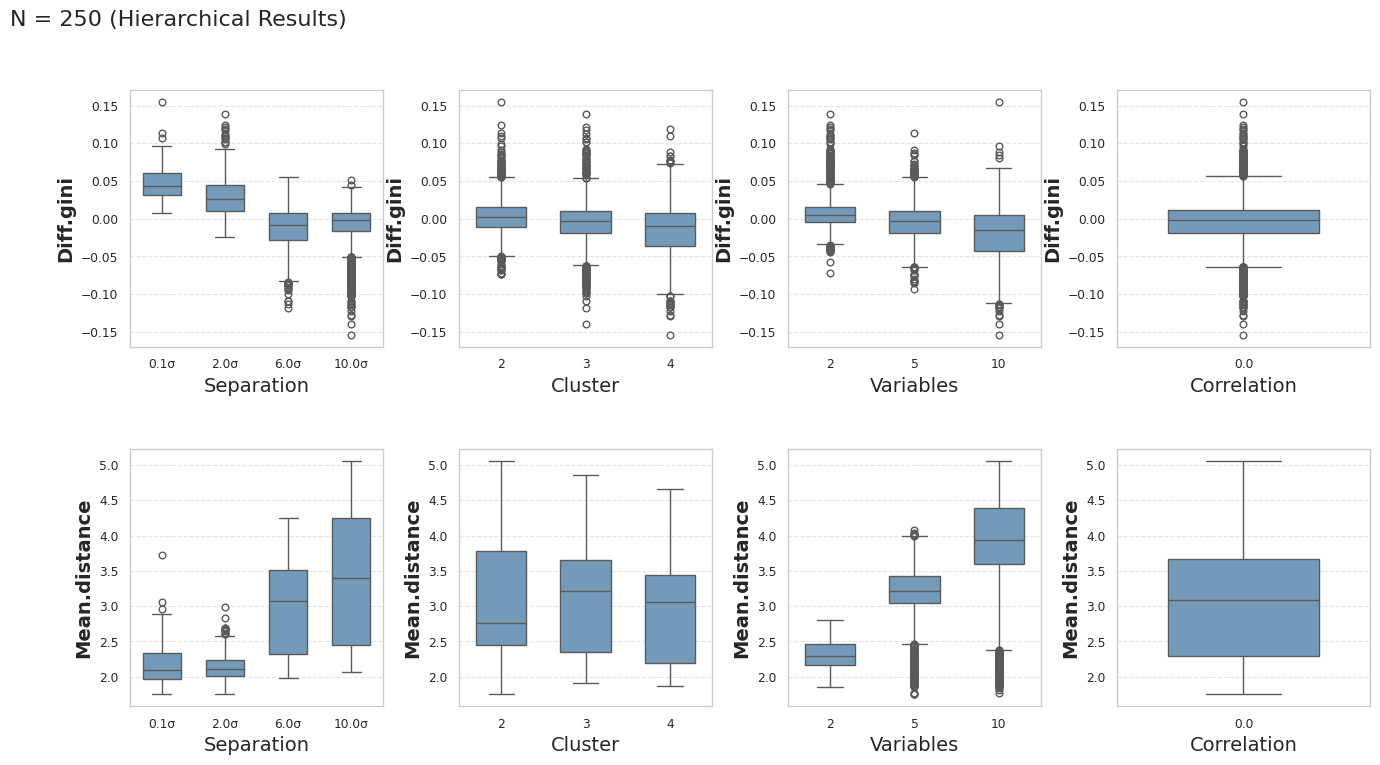

In [12]:
# ==========================================
# REPLACE: 1. HELPER - METRIC CALCULATION
# ==========================================
def calculate_metrics(data, labels, centroids):
    if len(np.unique(labels)) < 2:
        return np.nan, np.nan
    
    sil = silhouette_score(data, labels)
    
    if len(centroids) < 2:
        dist_mean = 0
    else:
        dists = cdist(centroids, centroids, metric='euclidean')
        dist_mean = dists[np.triu_indices(len(centroids), k=1)].mean()
        
    return sil, dist_mean

# ==========================================
# REPLACE: 2. SIMULATION LOGIC (HC VERSION)
# ==========================================
def simulate_one_run_detailed_hc(factor_combination, run_seed, total_m=50, max_attempts=200):
    N, p, k = factor_combination['N'], factor_combination['p'], factor_combination['k']
    rho, separation = factor_combination['rho'], factor_combination['separation']
    
    found_real = False
    real_data, k_real, hc_real_res = None, None, None
    
    for attempt in range(1, max_attempts + 1):
        seed = run_seed * 1000 + attempt
        np.random.seed(seed)
        try:
            real_data = generate_original_data(N, p, rho, separation, k, seed=seed)
            X_real = real_data.drop(columns=['group'])
            
            # Run HC Decision
            kd = k_decision_hierarchical(X_real, synthetic=False)
            k_real = kd['k_opt']
            
            if k_real == k:
                hc_real_res = kd
                found_real = True
                break
        except:
            continue
            
    if not found_real:
        return []

    # Calculate Real Metrics
    real_sil, _ = calculate_metrics(hc_real_res['scaled_data'], hc_real_res['labels'], hc_real_res['centroids'])
    
    results = []
    for i in range(1, total_m + 1):
        syn_seed = run_seed * 10000 + i
        np.random.seed(syn_seed)
        syn_data = generate_synthetic_cart(real_data, seed=syn_seed)
        X_syn = syn_data.drop(columns=['group'])
        
        # Run HC on Synthetic
        clust = k_decision_hierarchical(X_syn, k_real=k_real, synthetic=True)
        
        if clust is not None:
            # Synthetic Metrics
            syn_sil, syn_dist = calculate_metrics(clust['scaled_data'], clust['labels'], clust['centroids'])
            
            results.append({
                **factor_combination,
                'Diff_gini': syn_sil - real_sil,
                'Mean_distance': syn_dist
            })
            
    return results

# ==========================================
# REPLACE: 3. RUNNING & PLOTTING
# ==========================================
from scipy.spatial.distance import cdist

# ...existing code...
print(f"🚀 Starting Detailed HC Simulation...")
results_detailed = Parallel(n_jobs=-1)(
    delayed(simulate_one_run_detailed_hc)(params, run_seed=run, total_m=total_m)
    for params in tqdm(param_grid, desc="Processing")
    for run in range(1, n_runs + 1)
)

flat_results = [item for sublist in results_detailed for item in sublist]
df_box = pd.DataFrame(flat_results)
# ...existing code...

# --- PLOTTING CODE ---
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
plt.subplots_adjust(wspace=0.3, hspace=0.4)

labels_map = {'separation': 'Separation', 'k': 'Cluster', 'p': 'Variables', 'rho': 'Correlation'}
metrics = ['Diff_gini', 'Mean_distance']
y_labels = ['Diff.gini', 'Mean.distance']

for row_idx, metric in enumerate(metrics):
    sns.boxplot(x='separation', y=metric, data=df_box, ax=axes[row_idx, 0], color='#699bc4', width=0.6)
    axes[row_idx, 0].set_xticklabels([f'{x}σ' for x in sorted(df_box['separation'].unique())])
    
    sns.boxplot(x='k', y=metric, data=df_box, ax=axes[row_idx, 1], color='#699bc4', width=0.6)
    sns.boxplot(x='p', y=metric, data=df_box, ax=axes[row_idx, 2], color='#699bc4', width=0.6)
    sns.boxplot(x='rho', y=metric, data=df_box, ax=axes[row_idx, 3], color='#699bc4', width=0.6)

    for ax in axes[row_idx, :]:
        ax.set_ylabel(y_labels[row_idx], fontsize=14, fontweight='bold')
        ax.grid(axis='y', linestyle='--', alpha=0.5)

for i, key in enumerate(['separation', 'k', 'p', 'rho']):
    axes[0, i].set_xlabel(labels_map[key], fontsize=14)
    axes[1, i].set_xlabel(labels_map[key], fontsize=14)

fig.suptitle(f'N = {N_list[0]} (Hierarchical Results)', x=0.05, y=0.98, ha='left', fontsize=16)
plt.show()